# CKD Risk Prediction Demo

This notebook evaluates the saved KNN model and runs predictions on manually entered sample patients.

In [1]:
from pathlib import Path
import joblib
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
model = joblib.load(ROOT / 'models' / 'knn_ckd.pkl')
test = pd.read_csv(ROOT / 'data' / 'ckd_test.csv')
features = [column for column in test.columns if column != 'class']
print(f'Selected features: {features}')
test.head()

Selected features: ['hemo', 'pcv', 'sg', 'htn', 'rbcc']


,hemo,pcv,sg,htn,rbcc,class
0,15.00,50.0,1.020,0,6.3,0
1,8.80,31.0,1.010,1,4.8,1
2,12.65,40.0,1.015,0,4.8,1
3,15.00,46.0,1.025,0,5.3,0
4,12.60,40.0,1.025,0,4.8,1


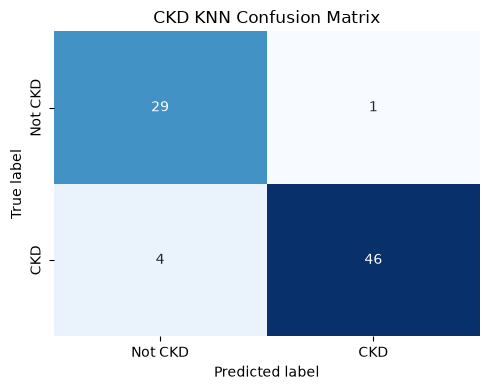

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

actual = test['class']
predicted = model.predict(test[features])
matrix = confusion_matrix(actual, predicted)
plt.figure(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Not CKD', 'CKD'], yticklabels=['Not CKD', 'CKD'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CKD KNN Confusion Matrix')
plt.tight_layout()
(ROOT / 'assets').mkdir(exist_ok=True)
plt.savefig(ROOT / 'assets' / 'confusion_matrix.png', dpi=160)
plt.show()

In [3]:
from sklearn.metrics import classification_report

print(classification_report(actual, predicted, target_names=['not CKD', 'CKD'], zero_division=0))

# Live demo: enter 2-3 patients using the selected features in this order.
sample_patients = pd.DataFrame([
    {'hemo': 15.0, 'pcv': 45.0, 'sg': 1.020, 'htn': 0, 'rbcc': 5.0},
    {'hemo': 9.8, 'pcv': 30.0, 'sg': 1.010, 'htn': 1, 'rbcc': 3.4},
    {'hemo': 12.5, 'pcv': 38.0, 'sg': 1.015, 'htn': 0, 'rbcc': 4.2},
])
sample_patients = sample_patients[features]
predictions = model.predict(sample_patients)
labels = ['CKD' if prediction == 1 else 'Not CKD' for prediction in predictions]
for number, label in enumerate(labels, start=1):
    print(f'Patient {number}: {label}')

              precision    recall  f1-score   support

     not CKD       0.88      0.97      0.92        30
         CKD       0.98      0.92      0.95        50

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80

Patient 1: Not CKD
Patient 2: CKD
Patient 3: CKD
